# Sales Forecasting — Tienda

This notebook builds a simple time-series forecast on the combined sales data using **statsmodels**.

Pipeline:
1. Load & prepare the data (monthly aggregation)
2. Visualize the historical trend
3. Fit an **Exponential Smoothing (Holt-Winters)** model
4. Forecast the next 3 months and plot the results

> **Why Holt-Winters?** It handles both trend and seasonality without requiring a large dataset, making it ideal for the ~1 year of data we have here.

## 1. Imports

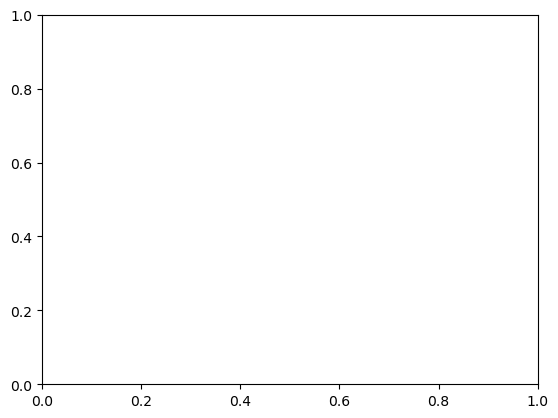

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import os
os.makedirs("charts", exist_ok=True)

fig, ax = plt.subplots()
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Load & Prepare Data

In [2]:
path1 = Path("Datos_Ventas_Tienda.csv")
path2 = Path("Datos_Ventas_Tienda2.csv")

df = pd.concat(
    [pd.read_csv(path1), pd.read_csv(path2)],
    ignore_index=True
)

df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"Date range: {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")
print(f"Total records: {len(df):,}")

Date range: 2023-01-01 → 2023-12-31
Total records: 1,050


In [3]:
# Aggregate to monthly total revenue
monthly = (
    df.groupby(df["Fecha"].dt.to_period("M"))["Total Venta"]
    .sum()
    .sort_index()
)

# Convert Period index to Timestamp for plotting & modeling
monthly.index = monthly.index.to_timestamp()

print("Monthly revenue:")
monthly

Monthly revenue:


Fecha
2023-01-01    43030
2023-02-01    28410
2023-03-01    23200
2023-04-01    23210
2023-05-01    39380
2023-06-01    30520
2023-07-01    26350
2023-08-01    45090
2023-09-01    27870
2023-10-01    25610
2023-11-01    21020
2023-12-01    33560
Freq: MS, Name: Total Venta, dtype: int64

## 3. Historical Trend

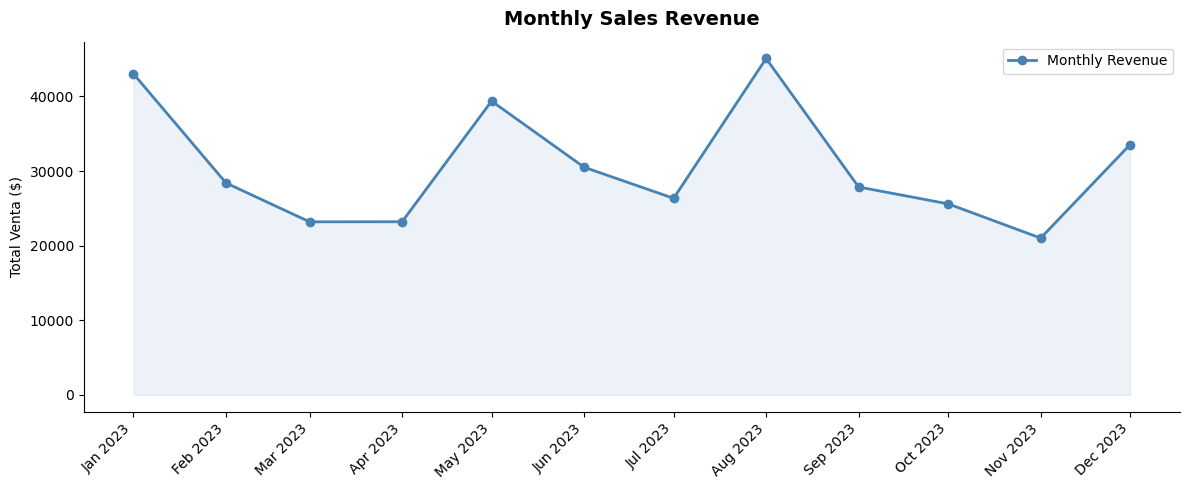

In [4]:
fig, ax = plt.subplots()

ax.plot(monthly.index, monthly.values, marker="o", linewidth=2,
        color="steelblue", label="Monthly Revenue")
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color="steelblue")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha="right")

ax.set_title("Monthly Sales Revenue", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Total Venta ($)")
ax.legend()

plt.tight_layout()
plt.savefig("charts/historical_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Fit Holt-Winters Model

We use **additive trend** and no seasonality component — with only 12 months of data there aren't enough full cycles to estimate a reliable seasonal pattern.

In [5]:
model = ExponentialSmoothing(
    monthly,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

print("Model fitted successfully.")
print(f"  Smoothing level (α): {model.params['smoothing_level']:.3f}")
print(f"  Smoothing trend (β): {model.params['smoothing_trend']:.3f}")

Model fitted successfully.
  Smoothing level (α): 0.000
  Smoothing trend (β): 0.000


## 5. Forecast — Next 3 Months

In [6]:
FORECAST_STEPS = 3

forecast = model.forecast(FORECAST_STEPS)
fitted = model.fittedvalues

print("Forecast:")
for date, value in forecast.items():
    print(f"  {date.strftime('%B %Y')}: ${value:,.0f}")

Forecast:
  January 2024: $27,933
  February 2024: $27,521
  March 2024: $27,110


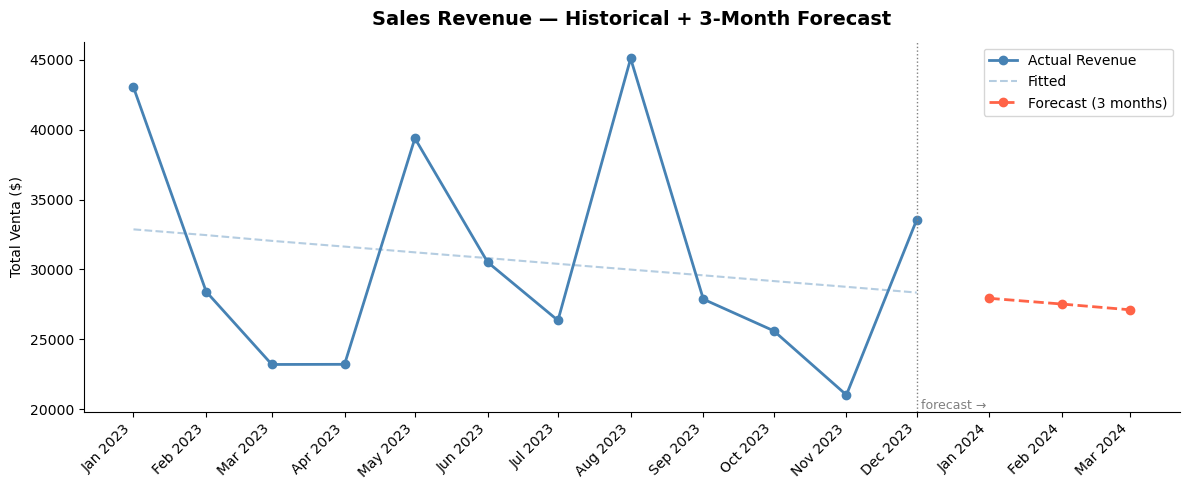

In [7]:
import os
os.makedirs("charts", exist_ok=True)

fig, ax = plt.subplots()

# Historical
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2,
        color="steelblue", label="Actual Revenue")

# Fitted
ax.plot(fitted.index, fitted.values, linewidth=1.5,
        color="steelblue", alpha=0.4, linestyle="--", label="Fitted")

# Forecast
ax.plot(forecast.index, forecast.values, marker="o", linewidth=2,
        color="tomato", linestyle="--", label="Forecast (3 months)")

# Vertical separator
ax.axvline(monthly.index[-1], color="gray", linestyle=":", linewidth=1)
ax.text(monthly.index[-1], ax.get_ylim()[0], " forecast →",
        color="gray", fontsize=9, va="bottom")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha="right")

ax.set_title("Sales Revenue — Historical + 3-Month Forecast",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Total Venta ($)")
ax.legend()

plt.tight_layout()
plt.savefig("charts/forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print(monthly)
print(f"\nNumber of months: {len(monthly)}")

Fecha
2023-01-01    43030
2023-02-01    28410
2023-03-01    23200
2023-04-01    23210
2023-05-01    39380
2023-06-01    30520
2023-07-01    26350
2023-08-01    45090
2023-09-01    27870
2023-10-01    25610
2023-11-01    21020
2023-12-01    33560
Freq: MS, Name: Total Venta, dtype: int64

Number of months: 12


In [ ]:
# Note: with only 12 months of data from a fake demo csv, this forecast should be interpreted
# as a demonstration of the method rather than a reliable prediction.
# A minimum of 2-3 years is recommended for robust time-series forecasting.